# Dataset 4: BETH Exploration (Phase 13)

**Goal:** The BETH dataset (Bank of England / Turing Honeypot) is completely unique compared to our other datasets. 
While the first three datasets monitored **Network Traffic** (routers, packets, IPs), BETH monitors **Host Activity** (Linux server system calls, kernel logs).

This is incredible for our AI, because it forces the model to detect hackers *after* they have already broken into the server!

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('ggplot')

### Step 1: Chronological Data Loading (Subphase 13.1)
Because BETH was captured on a real honeypot over several weeks, the rows are ordered chronologically by time. 
We will load the official training set and inspect the `timestamp` column.

In [2]:
# Load the BETH training dataset
file_path = "../data/raw/beth/labelled_training_data.csv"
df = pd.read_csv(file_path)

print(f"SUCCESS! Loaded {len(df):,} server events.")
print("\nNotice the 'timestamp' and 'processId' columns (Host-level features!):")
df[['timestamp', 'processId', 'threadId', 'sus', 'evil']].head()

SUCCESS! Loaded 763,144 server events.

Notice the 'timestamp' and 'processId' columns (Host-level features!):


,timestamp,processId,threadId,sus,evil
0,1809.495787,381,7337,1,0
1,1809.495832,381,7337,1,0
2,1809.495921,381,7337,1,0
3,1894.139651,7347,7347,1,0
4,1894.142127,7347,7347,1,0


### Step 2: The 'Sus' Class Distribution (Subphase 13.2)
In BETH, attacks are labeled in two ways:
1. `sus` (Suspicious - value is 1 if anomalous, 0 if normal)
2. `evil` (Confirmed malicious)

Let's plot the `sus` column to see how many suspicious events our honeypot captured.

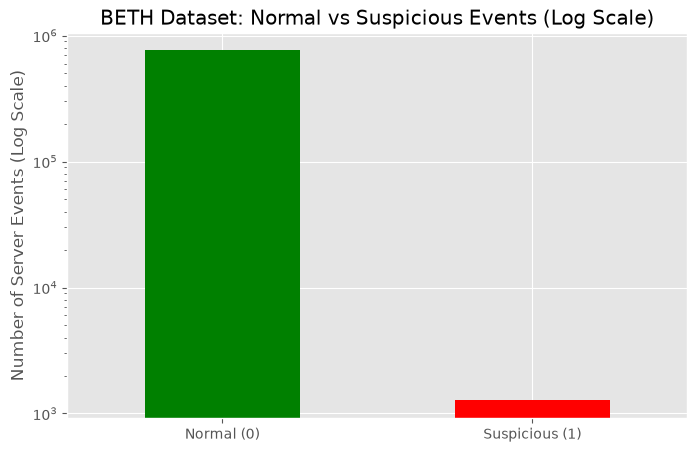

In [3]:
# Count normal vs suspicious events
sus_counts = df['sus'].value_counts()

# Map 0 to Normal and 1 to Suspicious for the chart labels
sus_counts.index = ['Normal (0)', 'Suspicious (1)']

plt.figure(figsize=(8, 5))
sus_counts.plot(kind='bar', color=['green', 'red'])

plt.yscale('log') # Log scale because normal events dominate heavily
plt.title("BETH Dataset: Normal vs Suspicious Events (Log Scale)")
plt.ylabel("Number of Server Events (Log Scale)")
plt.xticks(rotation=0)
plt.show()

### Step 3: Drift Windows & Temporal Plotting (Subphase 13.3)
Since this data is chronological, we can plot exactly *when* the hackers attacked the honeypot. 
Hackers usually attack in bursts (e.g., running an automated script that generates 5,000 suspicious events in 2 minutes).

Let's graph the attacks over time!

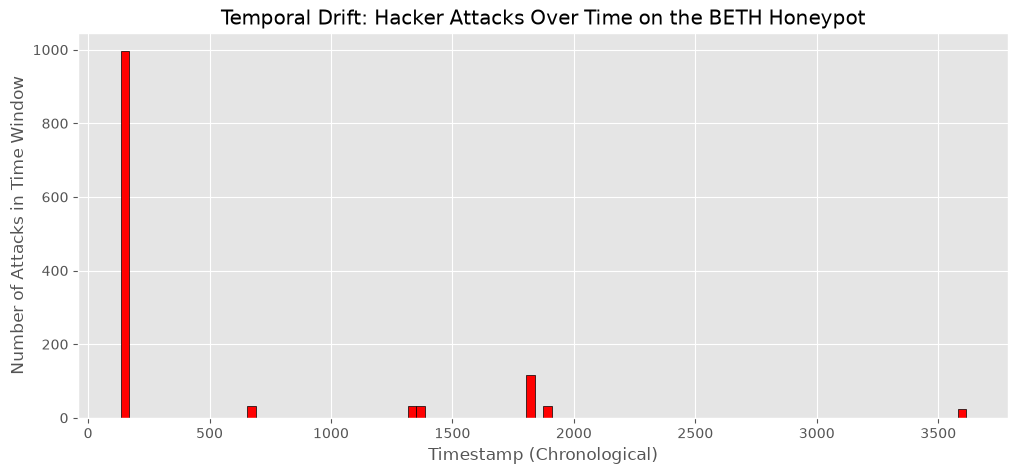

In [4]:
# 1. Filter to only show the suspicious events
attacks = df[df['sus'] == 1]

# 2. Group the attacks into 100 equally spaced time "buckets" (bins)
plt.figure(figsize=(12, 5))
plt.hist(attacks['timestamp'], bins=100, color='red', edgecolor='black')

plt.title("Temporal Drift: Hacker Attacks Over Time on the BETH Honeypot")
plt.xlabel("Timestamp (Chronological)")
plt.ylabel("Number of Attacks in Time Window")
plt.show()

---
### Step 3b: Per-Feature Drift Characterisation (Subphase 13.4)
We already proved that the *labels* (attacks) drift over time. But what about the *features* themselves?

If the internal system behavior naturally shifts over time (e.g., Linux starts assigning much higher `processId` numbers as the server stays online for weeks), our AI might get confused and think a high `processId` means an attack, when it just means the server has been on for a long time!

Let's track how the `processId` feature drifts over time.

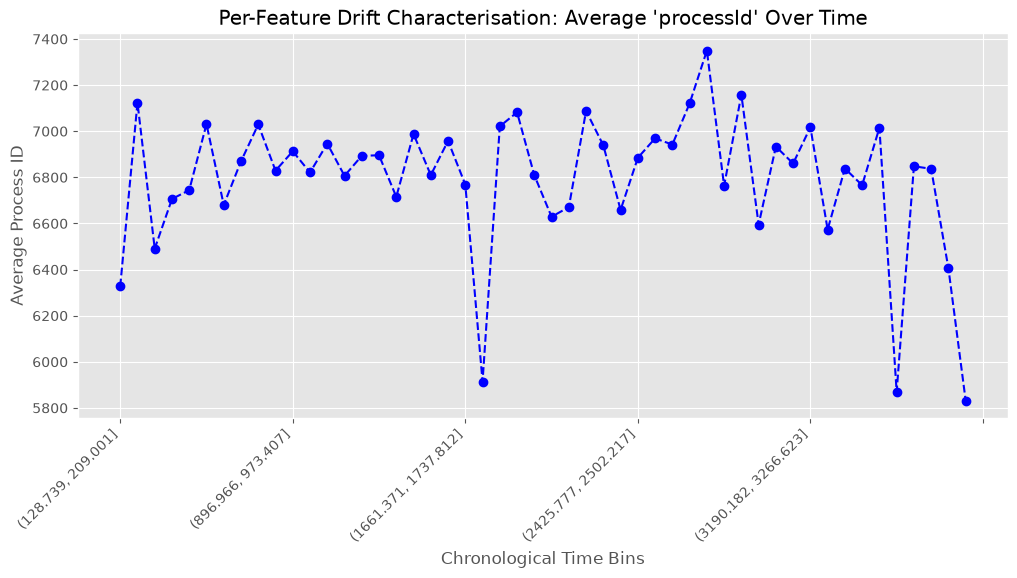

In [5]:
# 1. Split the entire timeline into 50 equal time chunks (bins)
df['time_bin'] = pd.cut(df['timestamp'], bins=50)

# 2. Calculate the average 'processId' in each time chunk
feature_drift = df.groupby('time_bin', observed=True)['processId'].mean()

# 3. Plot the feature's drift over time
plt.figure(figsize=(12, 5))
feature_drift.plot(color='blue', linestyle='--', marker='o')

plt.title("Per-Feature Drift Characterisation: Average 'processId' Over Time")
plt.xlabel("Chronological Time Bins")
plt.ylabel("Average Process ID")
plt.xticks(rotation=45, ha='right')
plt.show()

---
### Step 4: EDA Findings & Feature Gap Analysis (Subphase 13.4)
Here is the official **Action Plan** for the BETH dataset:

1. **Burst Attacks (Drift):** Our histogram in Step 3 proves that hackers attack in massive chronological bursts, followed by silence. 
   * **Action:** When we split our data for training later, we MUST use a strictly temporal split (e.g., train on the first 70% of time, test on the last 30%). If we use a random split, the AI will cheat by seeing the "future".
2. **Feature Gap Analysis:** 
   * Previous datasets had network features like `protocol_type` (TCP/UDP) and `src_bytes`.
   * BETH has host features like `processId` and `threadId`.
   * **Action:** This is the ultimate challenge of this research project! In the next phase, we will map these completely different datasets into a universal **Unified Schema** so one single AI model can understand both Networks AND Servers!